# Demo: Adaptive Bio-Signal DSP Pipeline (Project 2)

This notebook is a **self-contained, runnable demo** of the core algorithms in the pipeline, using a
synthetic EEG-like signal (no external dataset or internet connection required). It exists so a
reviewer can see every stage working end-to-end in a few minutes, without reading the full source
in `src/`.

For the real pipeline (loading the BCI Competition IV-2a dataset, CSP, the neural-network branch,
Cython-optimized filters), see `src/` and `docs/USER_GUIDE.md`.

**Covers:** synthetic signal generation &rarr; LMS filter &rarr; RLS filter &rarr; Wavelet band-power
features &rarr; fixed-point Q15 conversion + SQNR &rarr; MACs/second estimate.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pywt

rng = np.random.default_rng(42)
plt.rcParams["figure.figsize"] = (9, 3)

## 1. Synthetic EEG-like signal

We build a toy signal with three components, mirroring the kind of noise the real pipeline has to
handle:

- a "neural" component (alpha ~10&nbsp;Hz + beta ~20&nbsp;Hz bands, plus background noise)
- 50&nbsp;Hz powerline interference
- a short motion-artifact burst

This keeps the demo dependency-free (no dataset download) while still exercising every filter stage
on realistic-looking noise.

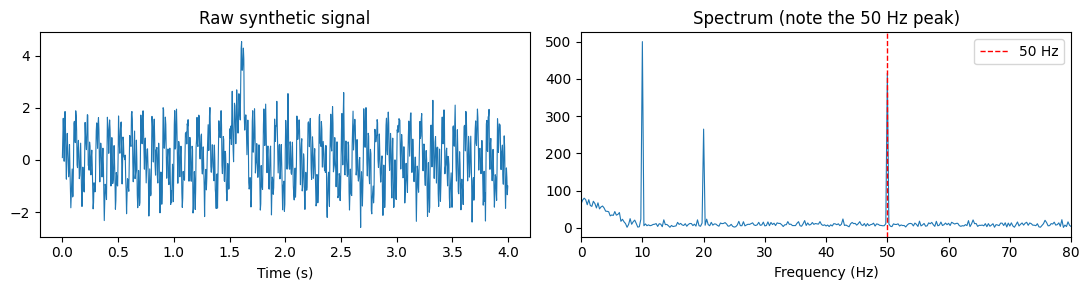

In [2]:
fs = 250            # Hz, typical EEG sampling rate
duration = 4.0       # seconds
n = int(fs * duration)
t = np.arange(n) / fs

neural = 1.0 * np.sin(2 * np.pi * 10 * t) + 0.5 * np.sin(2 * np.pi * 20 * t)
neural += 0.3 * rng.standard_normal(n)

powerline = 0.8 * np.sin(2 * np.pi * 50 * t)

artifact = np.zeros(n)
burst_start, burst_len = int(1.5 * fs), int(0.2 * fs)
artifact[burst_start:burst_start + burst_len] = 3.0 * np.hanning(burst_len)

x = neural + powerline + artifact   # observed noisy "EEG" channel

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].plot(t, x, lw=0.8)
axes[0].set_title("Raw synthetic signal")
axes[0].set_xlabel("Time (s)")

freqs = np.fft.rfftfreq(n, d=1 / fs)
spec = np.abs(np.fft.rfft(x))
axes[1].plot(freqs, spec, lw=0.8)
axes[1].axvline(50, color="r", ls="--", lw=1, label="50 Hz")
axes[1].set_xlim(0, 80)
axes[1].set_title("Spectrum (note the 50 Hz peak)")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].legend()
plt.tight_layout()
plt.show()

## 2. LMS adaptive filter (50&nbsp;Hz cancellation)

This is the classic adaptive line-canceller: a sinusoidal reference at 50&nbsp;Hz is used to let the
filter learn and subtract the interference. This is the simplest case of Week 1's LMS work
(`src/filters/lms.py` implements the general N-tap version used for motion-artifact removal against a
real reference channel).

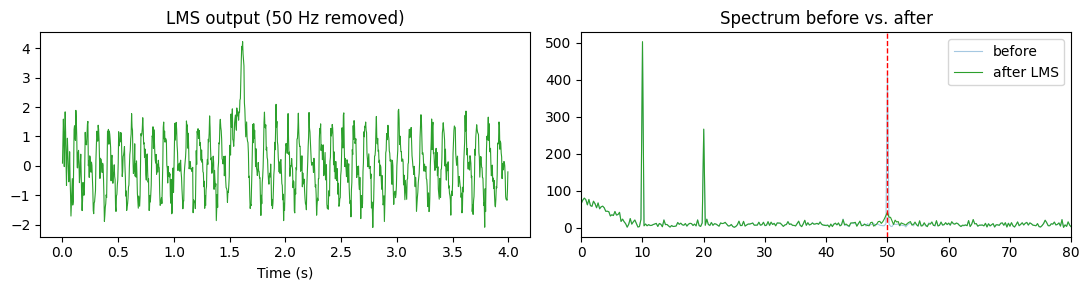

50 Hz magnitude before: 415.4
50 Hz magnitude after:  42.2


In [3]:
def lms_filter(d, ref, mu=0.02):
    n = len(d)
    w = 0.0
    y = np.zeros(n)
    e = np.zeros(n)
    for i in range(n):
        y[i] = w * ref[i]
        e[i] = d[i] - y[i]
        w = w + mu * e[i] * ref[i]
    return e, y

ref50 = np.sin(2 * np.pi * 50 * t)
e_lms, y_lms = lms_filter(x, ref50, mu=0.02)

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].plot(t, e_lms, lw=0.8, color="tab:green")
axes[0].set_title("LMS output (50 Hz removed)")
axes[0].set_xlabel("Time (s)")

spec_after = np.abs(np.fft.rfft(e_lms))
axes[1].plot(freqs, spec, lw=0.8, alpha=0.4, label="before")
axes[1].plot(freqs, spec_after, lw=0.8, color="tab:green", label="after LMS")
axes[1].axvline(50, color="r", ls="--", lw=1)
axes[1].set_xlim(0, 80)
axes[1].set_title("Spectrum before vs. after")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"50 Hz magnitude before: {spec[np.argmin(np.abs(freqs-50))]:.1f}")
print(f"50 Hz magnitude after:  {spec_after[np.argmin(np.abs(freqs-50))]:.1f}")

## 3. RLS adaptive filter (convergence comparison)

Same task, using RLS instead of LMS. RLS should converge in far fewer samples &mdash; this is the
trade-off the proposal's MACs analysis (Section&nbsp;6 of the roadmap) weighs against RLS's higher
computational cost.

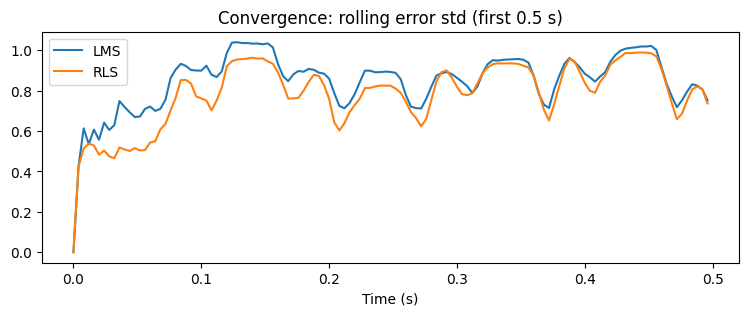

In [4]:
def rls_filter(d, ref, lam=0.99, delta=1.0):
    n = len(d)
    w = 0.0
    P = 1.0 / delta
    e = np.zeros(n)
    for i in range(n):
        pi = P * ref[i]
        k = pi / (lam + ref[i] * pi)
        y = w * ref[i]
        e[i] = d[i] - y
        w = w + k * e[i]
        P = (P - k * ref[i] * P) / lam
    return e

e_rls = rls_filter(x, ref50)

# convergence: rolling RMS of the error envelope around the 50 Hz component
win = 20
lms_env = np.array([np.std(e_lms[max(0,i-win):i+1]) for i in range(n)])
rls_env = np.array([np.std(e_rls[max(0,i-win):i+1]) for i in range(n)])

plt.figure()
plt.plot(t[:int(0.5*fs)], lms_env[:int(0.5*fs)], label="LMS")
plt.plot(t[:int(0.5*fs)], rls_env[:int(0.5*fs)], label="RLS")
plt.title("Convergence: rolling error std (first 0.5 s)")
plt.xlabel("Time (s)")
plt.legend()
plt.show()

## 4. Wavelet band-power features

Decompose the filtered signal with a discrete Wavelet Transform (Daubechies db4) and look at the
energy in each resulting band &mdash; the same idea used in Week 3 to build feature vectors for the
classifier.

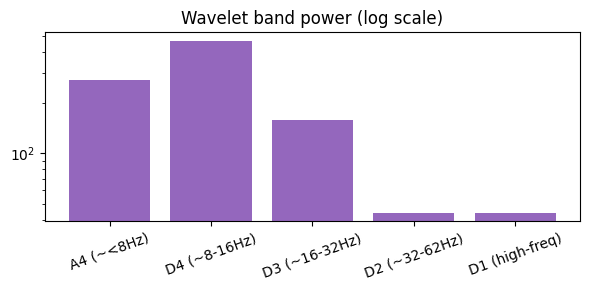

    A4 (~<8Hz): power = 270.72
  D4 (~8-16Hz): power = 465.46
 D3 (~16-32Hz): power = 157.06
 D2 (~32-62Hz): power = 44.11
D1 (high-freq): power = 44.23


In [5]:
coeffs = pywt.wavedec(e_lms, "db4", level=4)
band_names = ["A4 (~<8Hz)", "D4 (~8-16Hz)", "D3 (~16-32Hz)", "D2 (~32-62Hz)", "D1 (high-freq)"]
band_power = [float(np.sum(c ** 2)) for c in coeffs]

plt.figure(figsize=(6, 3))
plt.bar(band_names, band_power, color="tab:purple")
plt.title("Wavelet band power (log scale)")
plt.yscale("log")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

for name, p in zip(band_names, band_power):
    print(f"{name:>14}: power = {p:.2f}")

## 5. Fixed-point Q15 conversion &amp; SQNR

Convert the LMS output to the Q15/Q1.15 format (as planned for Week 5) and measure the
Signal-to-Quantization-Noise Ratio against the original floating-point signal. Note the signal is
normalized to `[-1, 1)` first &mdash; skipping this step is the most common cause of a bad SQNR
(see the Risk Analysis in the proposal).

SQNR (float32 vs. Q15): 87.95 dB   (target in proposal: >= 30 dB)


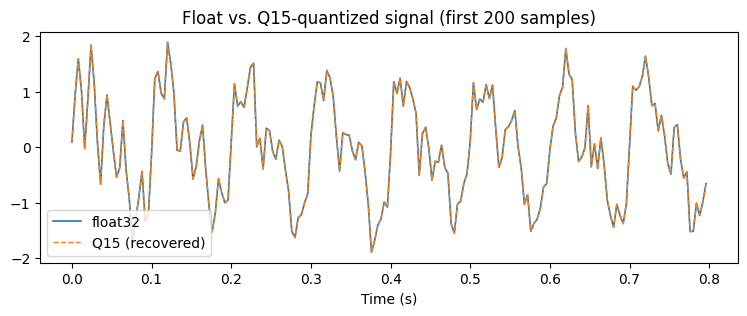

In [6]:
def float_to_q15(v):
    v = np.clip(v, -1.0, 0.9999695)
    return np.round(v * 32768).astype(np.int16)

def q15_to_float(q):
    return q.astype(np.float64) / 32768.0

def compute_sqnr(reference, test):
    signal_power = np.mean(reference ** 2)
    noise_power = np.mean((reference - test) ** 2)
    return 10 * np.log10(signal_power / noise_power)

scale = np.max(np.abs(e_lms)) * 1.05          # normalize into [-1, 1)
q15_vals = float_to_q15(e_lms / scale)
recovered = q15_to_float(q15_vals) * scale

sqnr = compute_sqnr(e_lms, recovered)
print(f"SQNR (float32 vs. Q15): {sqnr:.2f} dB   (target in proposal: >= 30 dB)")

plt.figure()
plt.plot(t[:200], e_lms[:200], label="float32", lw=1.2)
plt.plot(t[:200], recovered[:200], label="Q15 (recovered)", lw=1, ls="--")
plt.title("Float vs. Q15-quantized signal (first 200 samples)")
plt.xlabel("Time (s)")
plt.legend()
plt.show()

## 6. MACs/second estimate

Theoretical multiply-accumulate cost per second for LMS (`2N` per sample) vs. RLS (`4N^2` per
sample), for a few candidate filter orders `N`, at the sampling rate used above. This is the same
calculation Week 6 of the roadmap performs on the real filters.

In [7]:
def macs_lms(N, fs):
    return 2 * N * fs

def macs_rls(N, fs):
    return 4 * (N ** 2) * fs

print(f"{'N':>4} | {'LMS (MACs/s)':>14} | {'RLS (MACs/s)':>14}")
for N in [8, 16, 32, 64]:
    print(f"{N:>4} | {macs_lms(N, fs):>14,.0f} | {macs_rls(N, fs):>14,.0f}")

   N |   LMS (MACs/s) |   RLS (MACs/s)
   8 |          4,000 |         64,000
  16 |          8,000 |        256,000
  32 |         16,000 |      1,024,000
  64 |         32,000 |      4,096,000


## Next steps

- Real dataset loading, CSP, and the classical `LDA` classifier: `src/features/`, Week 4 of the
  roadmap.
- The AI/neural-network branch (EEGNet-style CNN + quantization-aware training): `src/models/`,
  Week 7 of the roadmap.
- Full setup and configuration reference: `docs/USER_GUIDE.md`.